<a href="https://colab.research.google.com/github/kxrrym03/Telecom-Customer-Churn/blob/main/Telecom_Subscription.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:
from google.colab import files
uploaded = files.upload()

Saving telecom_churn.csv to telecom_churn (1).csv


In [5]:
df = pd.read_csv('telecom_churn.csv')
df.shape

(50200, 18)

In [6]:
df.head()

,customer_id,signup_date,age,region,plan,tenure_months,num_devices,monthly_charges,discount_pct,is_autopay,avg_session_minutes,sessions_last_30d,last_login_days_ago,support_tickets_90d,payment_failures_12m,satisfaction_score,churn,total_charges
0,CUST0023588,2022-04-29,58.0,West,Standard,32,3,59.48,0,0,27.9,14,0,1,1,3.0,0,1903.36
1,CUST0006508,2022-03-11,47.0,West,Basic,34,4,40.57,25,0,23.2,17,4,1,0,5.0,0,1034.54
2,CUST0022185,2022-06-30,72.0,West,Premium,30,4,109.68,20,0,10.2,7,1,0,0,5.0,0,2632.32
3,CUST0046297,2023-06-05,63.0,South,Standard,19,1,57.78,5,0,NaN,13,7,3,2,3.0,0,1042.93
4,CUST0045641,2024-09-14,62.0,East,Premium,3,2,114.13,0,1,13.3,1,3,2,1,2.0,0,342.39


In [7]:
df.tail()

,customer_id,signup_date,age,region,plan,tenure_months,num_devices,monthly_charges,discount_pct,is_autopay,avg_session_minutes,sessions_last_30d,last_login_days_ago,support_tickets_90d,payment_failures_12m,satisfaction_score,churn,total_charges
50195,CUST0013928,2022-04-24,59.0,North,Basic,32,2,35.97,0,0,24.4,11,4,0,0,5.0,0,1151.04
50196,CUST0000920,2021-12-30,18.0,South,Standard,36,3,73.79,5,1,19.5,13,2,1,0,3.0,0,2523.62
50197,CUST0038468,2024-03-05,53.0,NORTH,Premium,10,3,108.50,0,0,17.1,6,9,0,0,3.0,0,1085.00
50198,CUST0010743,2024-07-11,23.0,South,Basic,5,5,54.19,0,1,20.8,11,2,1,0,NaN,0,270.95
50199,CUST0049690,2023-02-23,54.0,West,Standard,22,3,67.17,0,1,29.7,13,1,0,0,5.0,0,1477.74


In [8]:
df.isnull().sum()

,0
customer_id,0
signup_date,0
age,1505
region,0
plan,0
tenure_months,0
num_devices,0
monthly_charges,0
discount_pct,0
is_autopay,0


### Handling Missing Values



In [9]:
# Impute missing 'age' values with the median age
df['age'].fillna(df['age'].median(), inplace=True)

# Impute missing 'avg_session_minutes' values with the median
df['avg_session_minutes'].fillna(df['avg_session_minutes'].median(), inplace=True)

# Impute missing 'satisfaction_score' values with the median
df['satisfaction_score'].fillna(df['satisfaction_score'].median(), inplace=True)

# Impute missing 'total_charges' values with the median
df['total_charges'].fillna(df['total_charges'].median(), inplace=True)

print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
customer_id,0
signup_date,0
age,0
region,0
plan,0
tenure_months,0
num_devices,0
monthly_charges,0
discount_pct,0
is_autopay,0


In [10]:
df.duplicated().sum()

np.int64(200)

### Handling Duplicate Values



In [11]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Verify that duplicates have been removed
print("Number of duplicate rows after removal:")
display(df.duplicated().sum())

Number of duplicate rows after removal:


np.int64(0)

In [12]:
df.describe()

,age,tenure_months,num_devices,monthly_charges,discount_pct,is_autopay,avg_session_minutes,sessions_last_30d,last_login_days_ago,support_tickets_90d,payment_failures_12m,satisfaction_score,churn,total_charges
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000
mean,41.265800,21.985800,2.795060,60.394746,3.724800,0.565460,23.756023,10.325920,14.202420,0.83048,0.435360,3.205460,0.101840,1290.14499
std,13.254517,15.396269,1.340065,26.254118,7.368646,0.495701,17.697310,6.436092,18.802377,0.95900,0.676573,0.992424,0.302441,1130.68708
min,18.000000,0.000000,1.000000,11.060000,0.000000,0.000000,1.500000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,16.15000
25%,32.000000,11.000000,2.000000,37.780000,0.000000,0.000000,14.100000,6.000000,3.000000,0.00000,0.000000,3.000000,0.000000,521.88500
50%,41.000000,19.000000,3.000000,58.760000,0.000000,1.000000,20.100000,9.000000,8.000000,1.00000,0.000000,3.000000,0.000000,962.47000
75%,50.000000,30.000000,4.000000,73.040000,0.000000,1.000000,28.600000,13.000000,18.000000,1.00000,1.000000,4.000000,0.000000,1685.92250
max,88.000000,96.000000,9.000000,141.120000,25.000000,1.000000,643.666864,73.000000,180.000000,7.00000,5.000000,5.000000,1.000000,10705.92000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 50199
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           50000 non-null  object 
 1   signup_date           50000 non-null  object 
 2   age                   50000 non-null  float64
 3   region                50000 non-null  object 
 4   plan                  50000 non-null  object 
 5   tenure_months         50000 non-null  int64  
 6   num_devices           50000 non-null  int64  
 7   monthly_charges       50000 non-null  float64
 8   discount_pct          50000 non-null  int64  
 9   is_autopay            50000 non-null  int64  
 10  avg_session_minutes   50000 non-null  float64
 11  sessions_last_30d     50000 non-null  int64  
 12  last_login_days_ago   50000 non-null  int64  
 13  support_tickets_90d   50000 non-null  int64  
 14  payment_failures_12m  50000 non-null  int64  
 15  satisfaction_score    50

In [14]:
df.columns

Index(['customer_id', 'signup_date', 'age', 'region', 'plan', 'tenure_months',
       'num_devices', 'monthly_charges', 'discount_pct', 'is_autopay',
       'avg_session_minutes', 'sessions_last_30d', 'last_login_days_ago',
       'support_tickets_90d', 'payment_failures_12m', 'satisfaction_score',
       'churn', 'total_charges'],
      dtype='object')

In [15]:
df.dtypes

,0
customer_id,object
signup_date,object
age,float64
region,object
plan,object
tenure_months,int64
num_devices,int64
monthly_charges,float64
discount_pct,int64
is_autopay,int64


### Data Type Conversion



In [16]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

print("Data types after converting 'signup_date':")
display(df.info())

Data types after converting 'signup_date':
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 50199
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           50000 non-null  object        
 1   signup_date           50000 non-null  datetime64[ns]
 2   age                   50000 non-null  float64       
 3   region                50000 non-null  object        
 4   plan                  50000 non-null  object        
 5   tenure_months         50000 non-null  int64         
 6   num_devices           50000 non-null  int64         
 7   monthly_charges       50000 non-null  float64       
 8   discount_pct          50000 non-null  int64         
 9   is_autopay            50000 non-null  int64         
 10  avg_session_minutes   50000 non-null  float64       
 11  sessions_last_30d     50000 non-null  int64         
 12  last_login_days_ago   50000 non-null

None

## Exploratory Data Analysis (EDA) and Visualization



Churn Counts:


,count
churn,
0,44908
1,5092



Churn Ratios:


,proportion
churn,
0,0.89816
1,0.10184


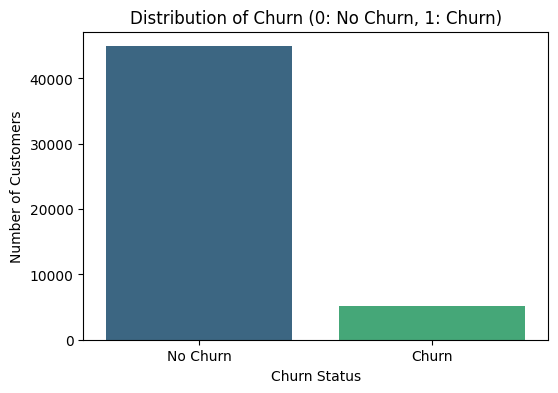

In [17]:
# Analyze Churn Distribution
churn_counts = df['churn'].value_counts()
churn_ratios = df['churn'].value_counts(normalize=True)

print("Churn Counts:")
display(churn_counts)
print("\nChurn Ratios:")
display(churn_ratios)

fig = plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='viridis')
plt.title('Distribution of Churn (0: No Churn, 1: Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

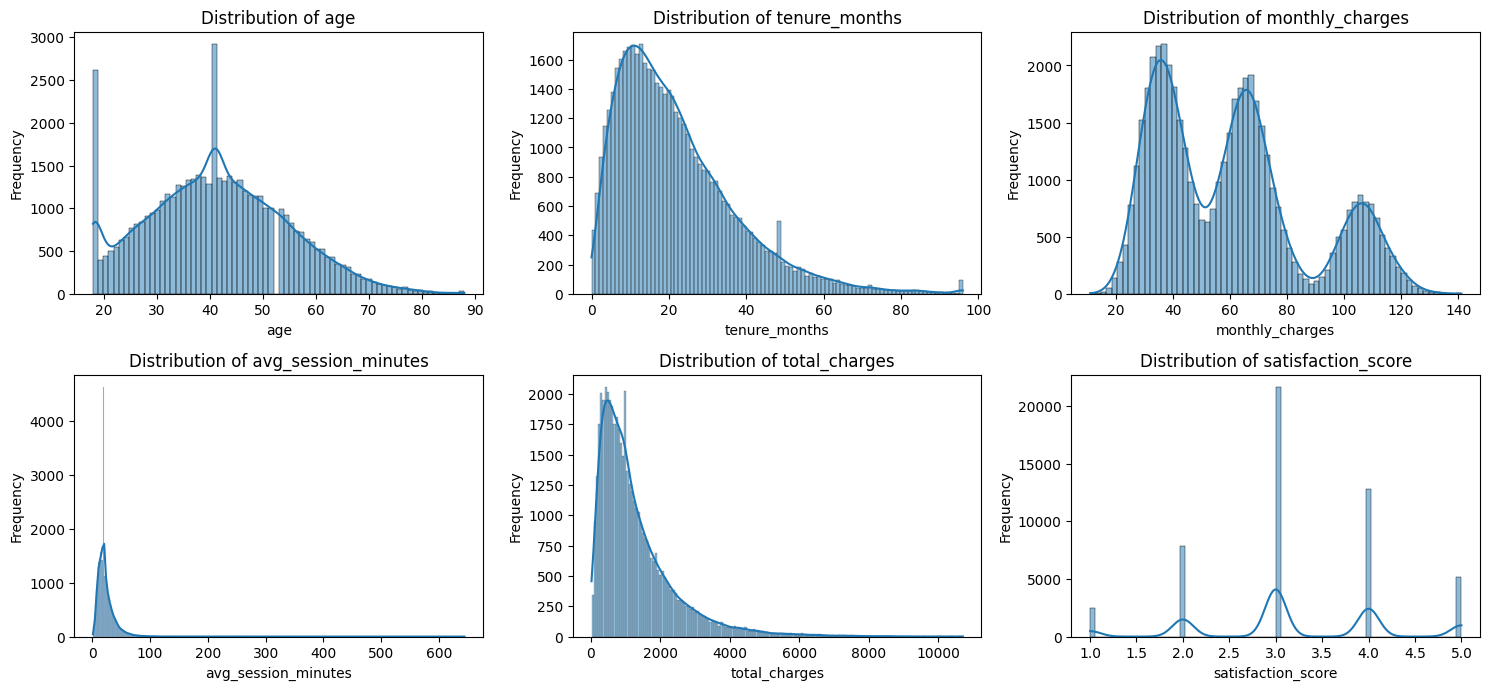

In [18]:
# Distribution of Numerical Features

numerical_cols = ['age', 'tenure_months', 'monthly_charges', 'avg_session_minutes', 'total_charges', 'satisfaction_score']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Churn Status by Region



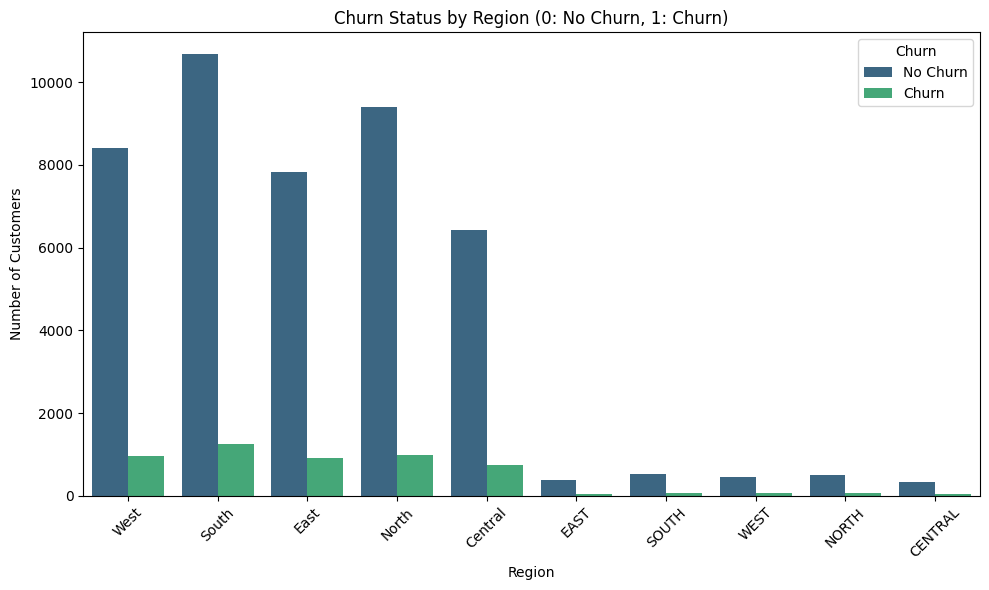

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='region', hue='churn', palette='viridis')
plt.title('Churn Status by Region (0: No Churn, 1: Churn)')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

### Regional Churn Rate Percentage



In [20]:
regional_churn_rate = df.groupby('region')['churn'].mean() * 100
regional_churn_rate = regional_churn_rate.sort_values(ascending=False)

print("Churn Rate Percentage by Region:")
display(regional_churn_rate)

Churn Rate Percentage by Region:


,churn
region,
SOUTH,11.505922
WEST,10.852713
NORTH,10.771993
Central,10.494085
South,10.424710
East,10.376061
West,10.150818
CENTRAL,9.641873
North,9.514638


### Churn Rate by Plan Type



In [21]:
churn_rate_by_plan = df.groupby('plan')['churn'].mean() * 100
churn_rate_by_plan = churn_rate_by_plan.sort_values(ascending=False)

print("Churn Rate Percentage by Plan Type:")
display(churn_rate_by_plan)

Churn Rate Percentage by Plan Type:


,churn
plan,
Premium,11.127433
Basic,11.123399
Premium,9.854015
Basic,9.701493
Standard,8.786363
Standard,7.312925


### Visualize Churn Rate by Plan Type



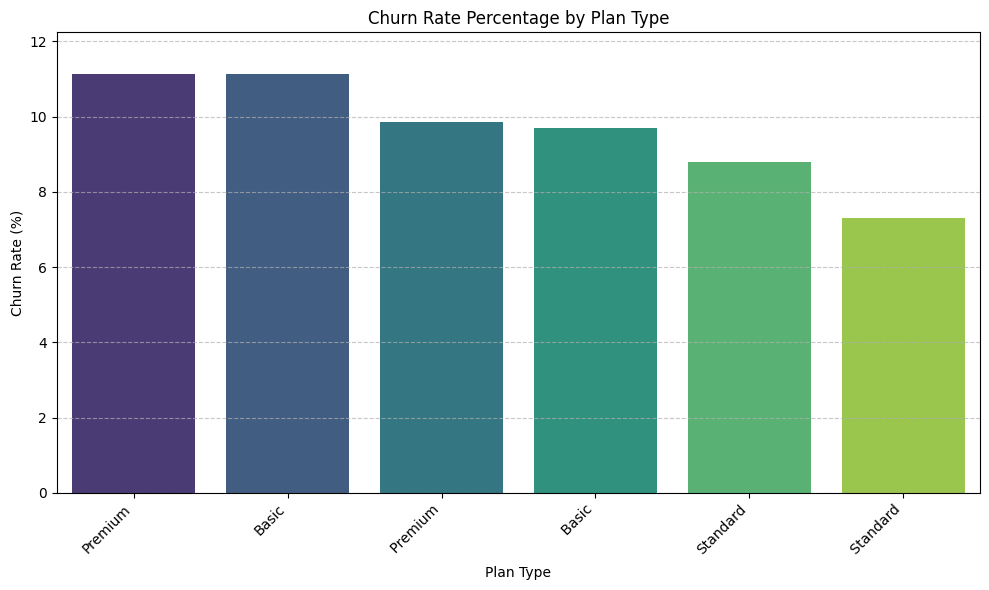

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=churn_rate_by_plan.index, y=churn_rate_by_plan.values, palette='viridis')
plt.title('Churn Rate Percentage by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, churn_rate_by_plan.max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Box Plot of Total Charges by Churn Status



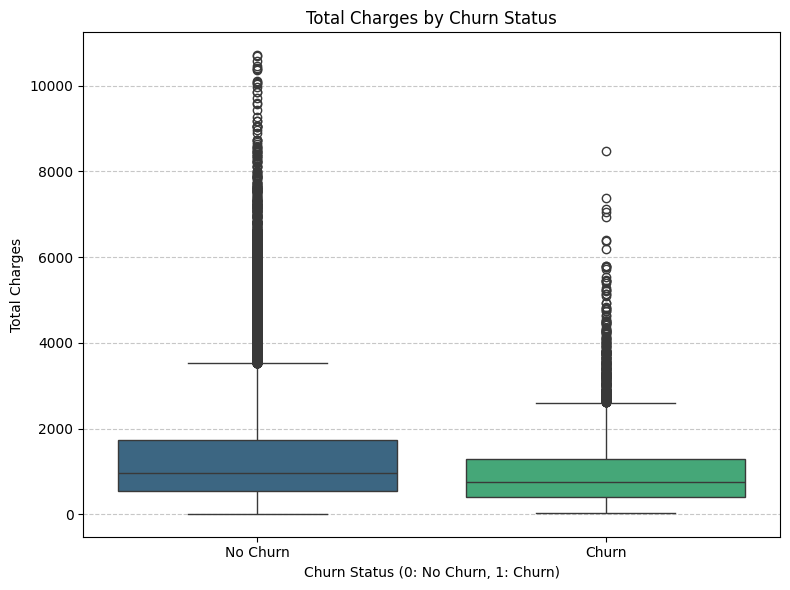

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='churn', y='total_charges', palette='viridis')
plt.title('Total Charges by Churn Status')
plt.xlabel('Churn Status (0: No Churn, 1: Churn)')
plt.ylabel('Total Charges')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Heatmap of Numerical Variables



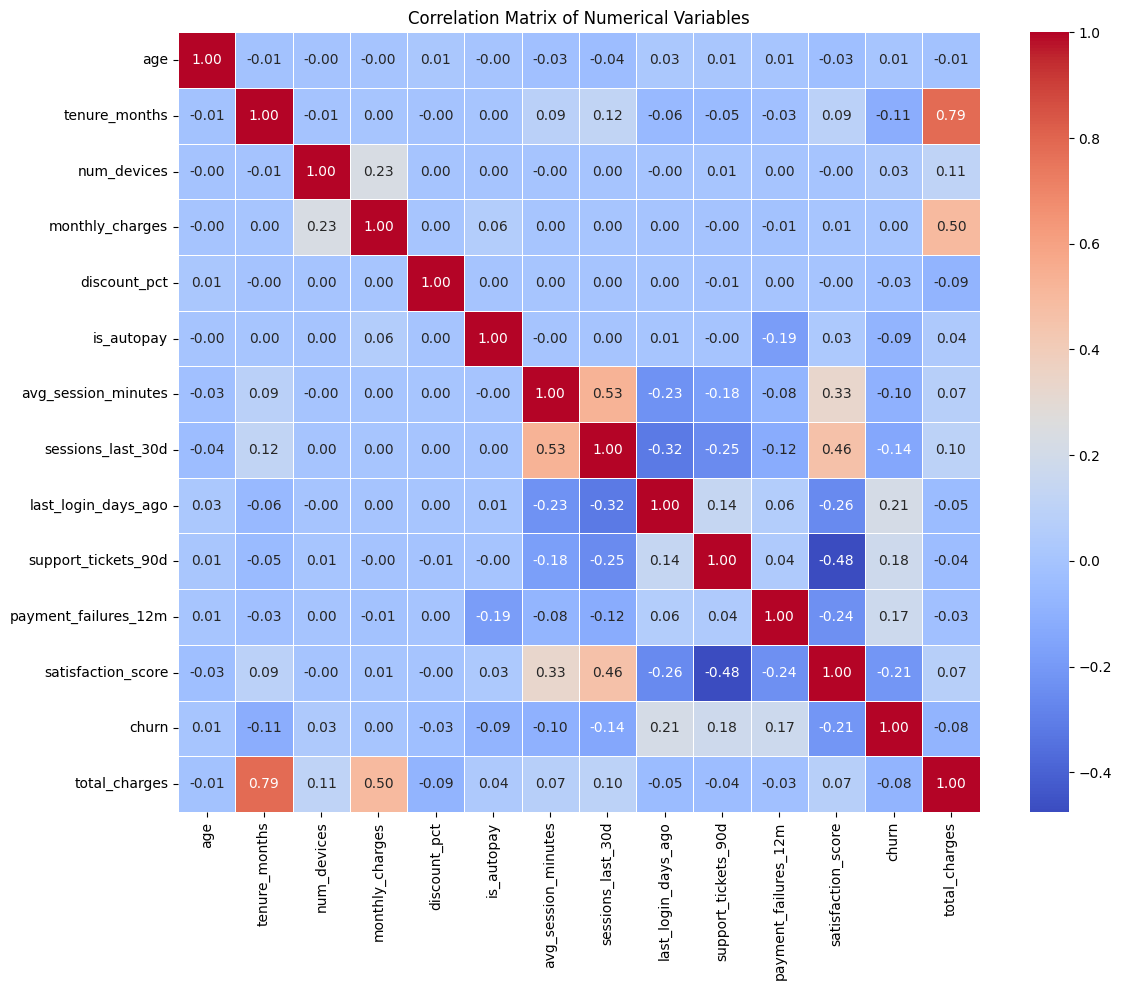

In [24]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()